<a href="https://colab.research.google.com/github/ds-3289/Urban-Air-Quality-Predictor/blob/main/Urban_Air_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving air_quality_dataset.zip to air_quality_dataset.zip


In [ ]:
!unzip air_quality_dataset.zip

Archive:  air_quality_dataset.zip
  inflating: Air Quality.csv         


In [ ]:
!ls

'Air Quality.csv'   air_quality_dataset.zip   sample_data


In [ ]:
import pandas as pd

data = pd.read_csv("Air Quality.csv")


In [ ]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [ ]:
data.shape

(9471, 17)

In [ ]:
data.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [ ]:
data = data.drop(columns=["Unnamed: 15", "Unnamed: 16"])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [ ]:
data.isnull().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [ ]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [ ]:
data.isnull().sum()

,0
Date,114
Time,114
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [ ]:
data.duplicated().sum()

np.int64(113)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data["Datetime"] = pd.to_datetime(data["Date"] + " " + data["Time"], dayfirst=True)

In [ ]:
data.drop(columns=["Date", "Time"], inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9358 entries, 0 to 9357
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         9358 non-null   float64       
 1   PT08.S1(CO)    9358 non-null   float64       
 2   NMHC(GT)       9358 non-null   float64       
 3   C6H6(GT)       9358 non-null   float64       
 4   PT08.S2(NMHC)  9358 non-null   float64       
 5   NOx(GT)        9358 non-null   float64       
 6   PT08.S3(NOx)   9358 non-null   float64       
 7   NO2(GT)        9358 non-null   float64       
 8   PT08.S4(NO2)   9358 non-null   float64       
 9   PT08.S5(O3)    9358 non-null   float64       
 10  T              9358 non-null   float64       
 11  RH             9358 non-null   float64       
 12  AH             9358 non-null   float64       
 13  Datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(13)
memory usage: 1.1 MB


In [ ]:
data.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [ ]:
data.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9357
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604,2004-09-21 16:00:00
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,2004-03-10 18:00:00
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692150,2004-06-16 05:00:00
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.550000,0.976800,2004-09-21 16:00:00
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296100,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,77.653021,329.815084,139.781623,41.377995,342.314958,257.420110,321.976345,126.933672,467.185158,456.913767,43.201314,51.213408,38.974587,NaN


In [ ]:
import numpy as np

data.replace(-200, np.nan, inplace=True)

In [ ]:
data.isnull().sum()

,0
CO(GT),1683
PT08.S1(CO),366
NMHC(GT),8443
C6H6(GT),366
PT08.S2(NMHC),366
NOx(GT),1639
PT08.S3(NOx),366
NO2(GT),1642
PT08.S4(NO2),366
PT08.S5(O3),366


In [ ]:
data = data.drop(columns=["NMHC(GT)"])

In [ ]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [ ]:
data.isnull().sum()

,0
CO(GT),0
PT08.S1(CO),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0
PT08.S5(O3),0
T,0


In [ ]:
data = data.dropna(subset=["Datetime"])

In [ ]:
data = data.sort_values("Datetime")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         9357 non-null   float64       
 1   PT08.S1(CO)    9357 non-null   float64       
 2   C6H6(GT)       9357 non-null   float64       
 3   PT08.S2(NMHC)  9357 non-null   float64       
 4   NOx(GT)        9357 non-null   float64       
 5   PT08.S3(NOx)   9357 non-null   float64       
 6   NO2(GT)        9357 non-null   float64       
 7   PT08.S4(NO2)   9357 non-null   float64       
 8   PT08.S5(O3)    9357 non-null   float64       
 9   T              9357 non-null   float64       
 10  RH             9357 non-null   float64       
 11  AH             9357 non-null   float64       
 12  Datetime       9357 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(12)
memory usage: 1023.4 KB


In [ ]:
data.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
count,9357.000000,9357.000000,9357.00000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357
mean,2.151897,1099.832945,10.08307,939.153182,246.894959,835.493429,113.090001,1456.264316,1022.905920,18.317792,49.234158,1.025496,2004-09-21 16:00:00
min,0.100000,647.000000,0.10000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.200000,941.000000,4.60000,743.000000,112.000000,666.000000,86.000000,1242.000000,742.000000,12.000000,36.600000,0.746100,2004-06-16 05:00:00
50%,2.148012,1075.000000,8.60000,923.000000,229.000000,818.000000,113.084130,1456.257393,983.000000,18.300000,49.233117,1.015400,2004-09-21 16:00:00
75%,2.600000,1221.000000,13.60000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200,2004-12-28 03:00:00
max,11.900000,2040.000000,63.70000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.316070,212.791672,7.30265,261.560236,193.426632,251.743954,43.920954,339.367559,390.612324,8.657639,16.974801,0.395835,NaN


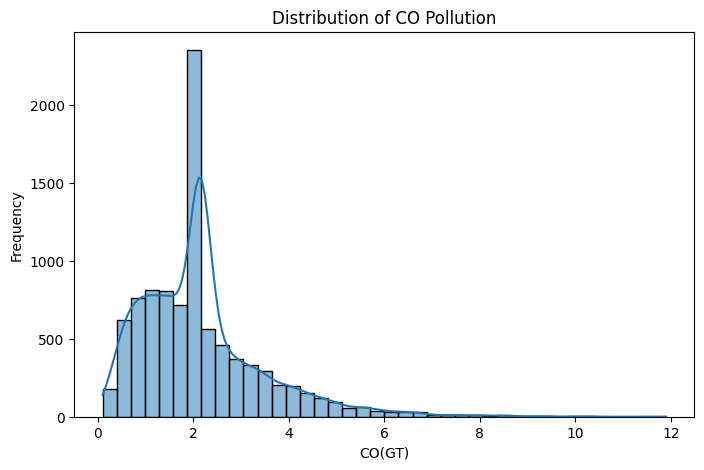

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data["CO(GT)"], bins=40, kde=True)

plt.title("Distribution of CO Pollution")
plt.xlabel("CO(GT)")
plt.ylabel("Frequency")

plt.show()

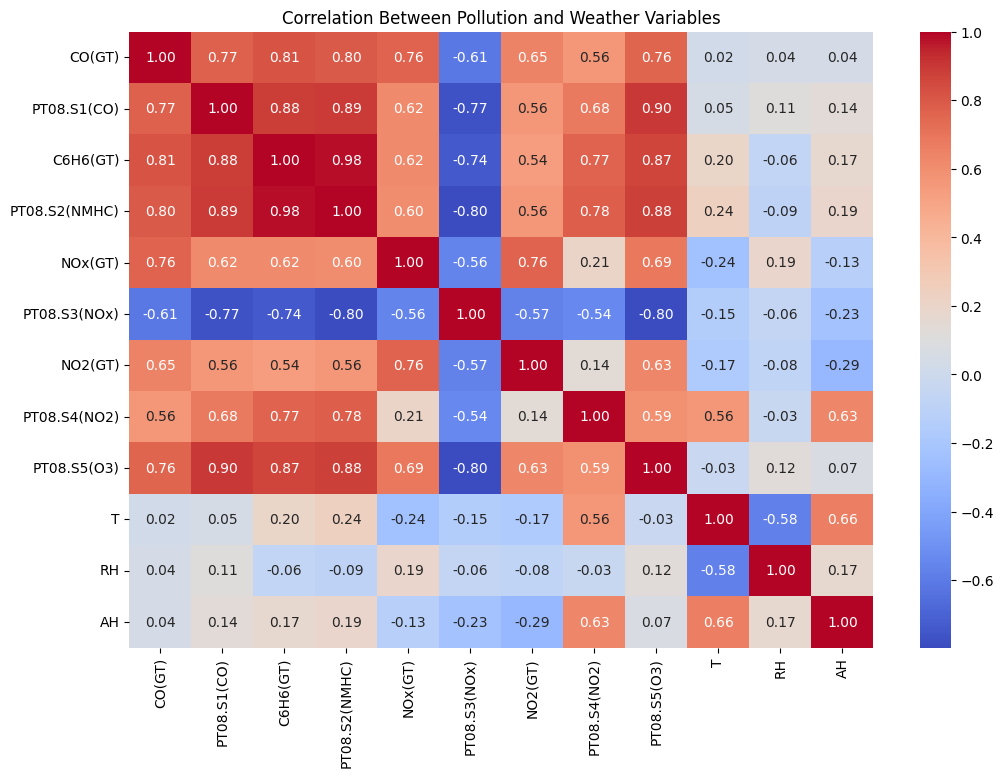

In [ ]:
plt.figure(figsize=(12,8))

corr = data.drop(columns=["Datetime"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Pollution and Weather Variables")

plt.show()

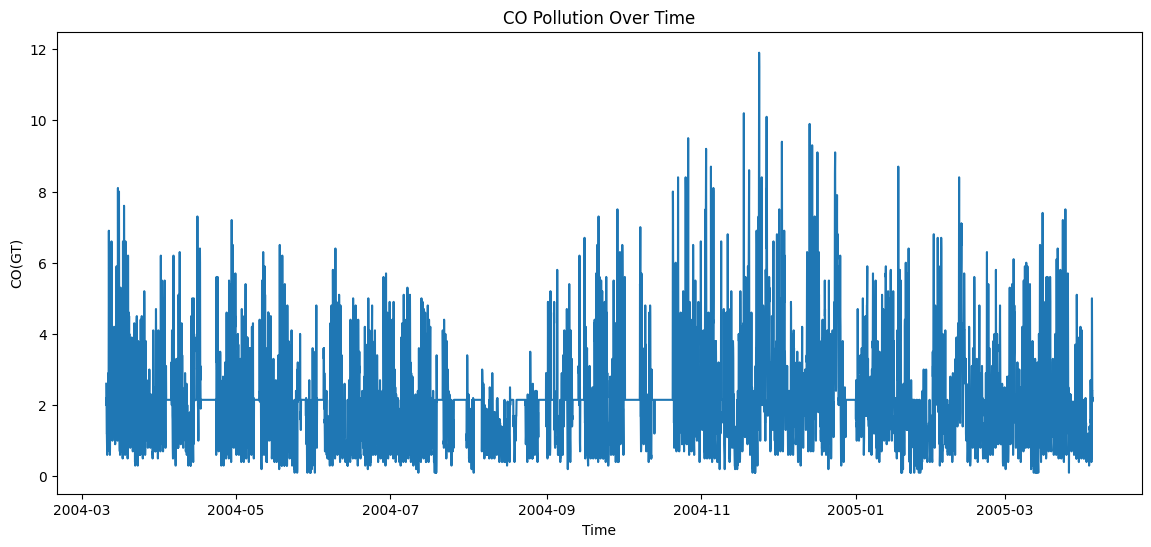

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(data["Datetime"], data["CO(GT)"])

plt.title("CO Pollution Over Time")
plt.xlabel("Time")
plt.ylabel("CO(GT)")

plt.show()

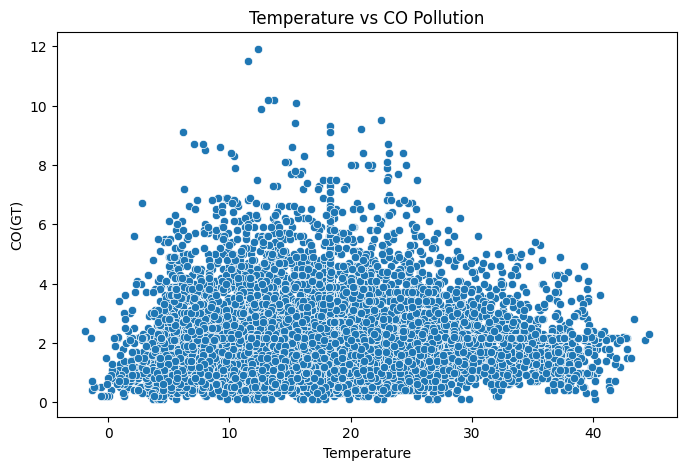

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=data["T"], y=data["CO(GT)"])

plt.title("Temperature vs CO Pollution")
plt.xlabel("Temperature")
plt.ylabel("CO(GT)")

plt.show()

In [ ]:
X = data.drop(columns=["CO(GT)", "Datetime"])

In [ ]:
X.head()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [ ]:
y = data["CO(GT)"]

In [ ]:
y.head()

,CO(GT)
0,2.6
1,2.0
2,2.2
3,2.2
4,1.6


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [ ]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
X_scaled.head()

,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1.222703,0.248818,0.408520,-0.418243,0.875963,-0.002049,0.694669,0.627495,-0.544957,-0.019687,-0.676317
1,0.903124,-0.093542,0.060589,-0.743965,1.344718,-0.480207,0.302743,-0.130330,-0.579611,-0.090383,-0.757921
2,1.420089,-0.148320,-0.000586,-0.599200,1.209653,0.020720,0.290956,0.130812,-0.741326,0.280775,-0.695518
3,1.297898,-0.120931,0.033825,-0.387222,1.018973,0.202875,0.376413,0.461080,-0.845286,0.634259,-0.603303
4,0.809131,-0.490680,-0.394397,-0.599200,1.467866,0.066259,0.099413,0.222980,-0.822184,0.610693,-0.597998


In [ ]:
print("Feature matrix shape:", X_scaled.shape)
print("Target shape:", y.shape)

Feature matrix shape: (9357, 11)
Target shape: (9357,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,   # features
    y,          # target variable
    test_size=0.2,   # 20% test data
    random_state=42  # ensures same split every run
)

In [ ]:
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (7485, 11)
Testing features shape: (1872, 11)
Training target shape: (7485,)
Testing target shape: (1872,)


In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
#Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [ ]:
#Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [ ]:
#K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [ ]:
#Support Vector Regressor
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Linear Regression R2: 0.8136460553757937
Random Forest R2: 0.873699506837879
Decision Tree R2: 0.7397322417330171


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


# Decision Tree
print("\nDecision Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))


# Random Forest
print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Linear Regression
MAE: 0.39626608097429605
MSE: 0.34598115524752576
R2: 0.8136460553757937

Decision Tree
MAE: 0.4278013979560798
MSE: 0.483208122374233
R2: 0.7397322417330171

Random Forest
MAE: 0.31573141987667785
MSE: 0.234487070400799
R2: 0.873699506837879


In [ ]:
results = {}

# Linear Regression
results["Linear"] = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_lr),
    r2_score(y_test, y_pred_lr)
]

# Decision Tree
results["Decision Tree"] = [
    mean_absolute_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_dt),
    r2_score(y_test, y_pred_dt)
]

# Random Forest
results["Random Forest"] = [
    mean_absolute_error(y_test, y_pred_rf),
    mean_squared_error(y_test, y_pred_rf),
    r2_score(y_test, y_pred_rf)
]

In [ ]:
models = list(results.keys())

mae = [results[m][0] for m in models]
mse = [results[m][1] for m in models]
r2 = [results[m][2] for m in models]

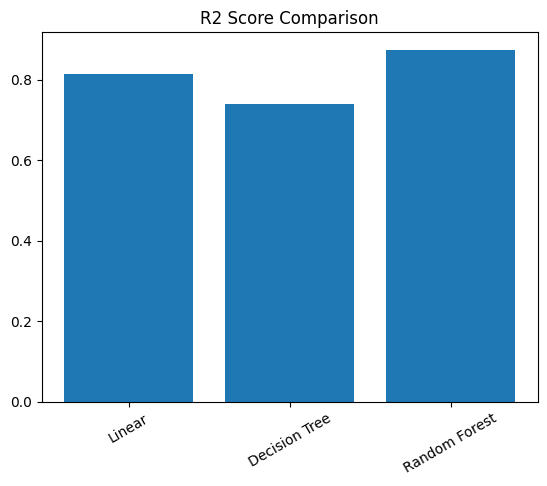

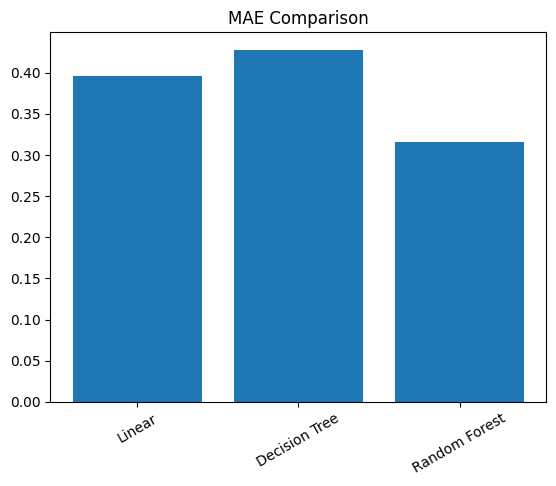

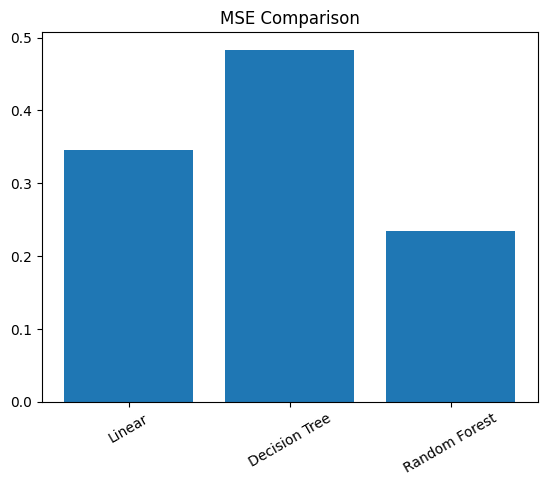

In [ ]:
import matplotlib.pyplot as plt

# R2 Graph
plt.figure()
plt.bar(models, r2)
plt.title("R2 Score Comparison")
plt.xticks(rotation=30)
plt.show()

# MAE Graph
plt.figure()
plt.bar(models, mae)
plt.title("MAE Comparison")
plt.xticks(rotation=30)
plt.show()

# MSE Graph
plt.figure()
plt.bar(models, mse)
plt.title("MSE Comparison")
plt.xticks(rotation=30)
plt.show()

In [ ]:
best_r2_model = models[r2.index(max(r2))]
best_mae_model = models[mae.index(min(mae))]
best_mse_model = models[mse.index(min(mse))]

print("Best (R2):", best_r2_model)
print("Best (MAE):", best_mae_model)
print("Best (MSE):", best_mse_model)

Best (R2): Random Forest
Best (MAE): Random Forest
Best (MSE): Random Forest


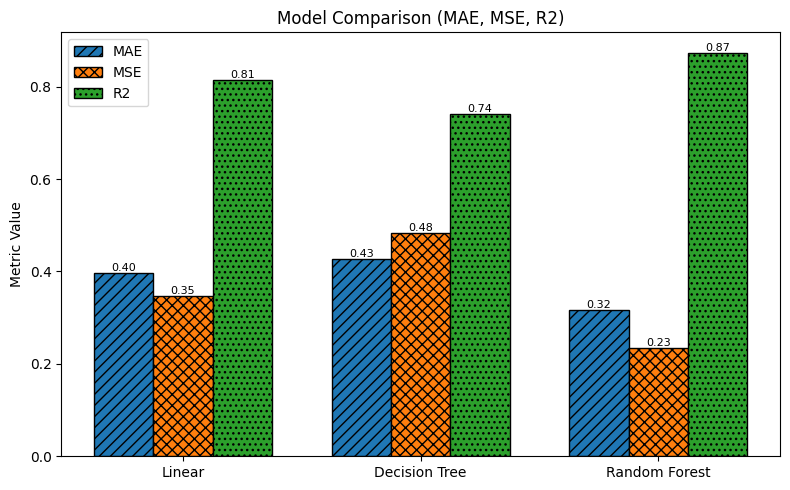

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = ["Linear", "Decision Tree", "Random Forest"]

# Metrics
mae = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

mse = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

r2 = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

# X positions
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

# Black & white friendly bars
bars1 = plt.bar(x - width, mae, width, label="MAE", hatch='///', edgecolor='black')
bars2 = plt.bar(x, mse, width, label="MSE", hatch='xxx', edgecolor='black')
bars3 = plt.bar(x + width, r2, width, label="R2", hatch='...', edgecolor='black')

# Labels
plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Model Comparison (MAE, MSE, R2)")
plt.legend()

# Add value labels (important for print)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.savefig("model_comparison_mse.png", dpi=300)

plt.show()

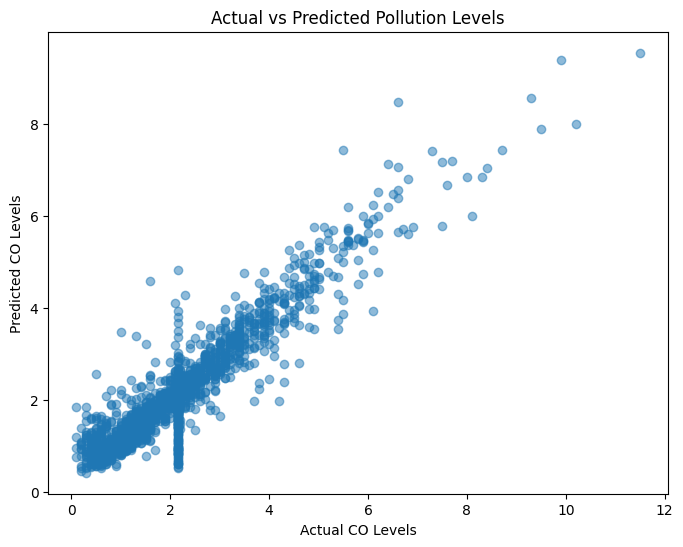

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual CO Levels")
plt.ylabel("Predicted CO Levels")

plt.title("Actual vs Predicted Pollution Levels")

plt.show()

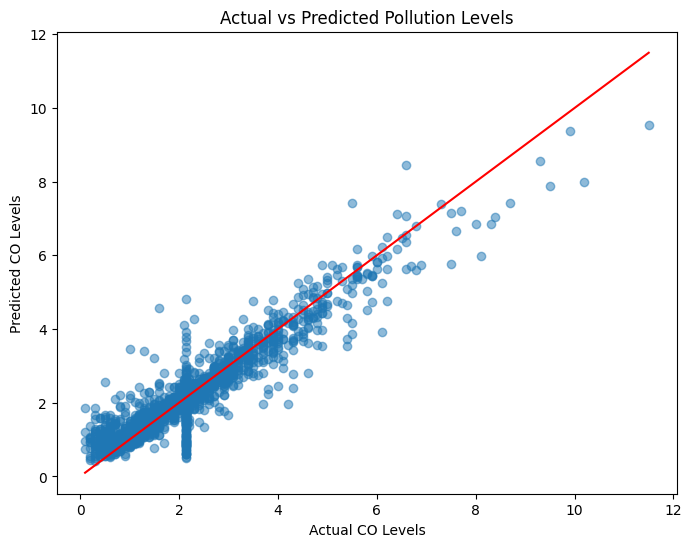

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual CO Levels")
plt.ylabel("Predicted CO Levels")

plt.title("Actual vs Predicted Pollution Levels")

plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
2   PT08.S2(NMHC)    0.495257
3         NOx(GT)    0.188781
1        C6H6(GT)    0.134860
0     PT08.S1(CO)    0.053636
5         NO2(GT)    0.029661
8               T    0.021649
7     PT08.S5(O3)    0.019342
4    PT08.S3(NOx)    0.016558
6    PT08.S4(NO2)    0.014805
9              RH    0.013467
10             AH    0.011984


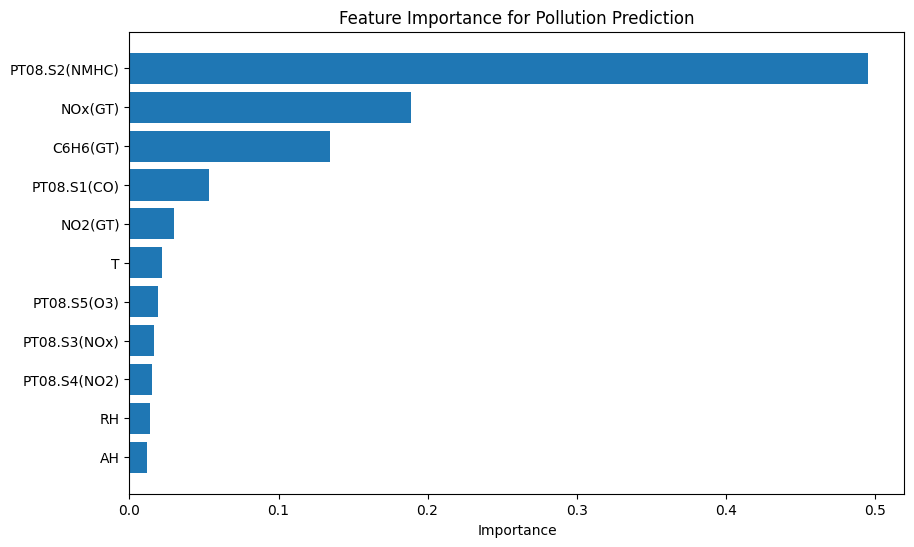

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(feature_importance["Feature"],
         feature_importance["Importance"])

plt.xlabel("Importance")
plt.title("Feature Importance for Pollution Prediction")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import numpy as np

new_data = np.array([[1400, 10.5, 1000, 150, 1100, 100, 1600, 1200, 30, 70, 0.85]])

In [ ]:
new_data_scaled = scaler.transform(new_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = rf.predict(new_data_scaled)

print("Predicted CO Level:", prediction[0])

Predicted CO Level: 2.169281325392093


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

joblib.dump(rf, "air_quality_model.pkl")

['air_quality_model.pkl']